<a href="https://colab.research.google.com/github/anyuanay/INFO213/blob/main/INFO213_Week8_PCA_and_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# INFO 213: Data Science Programming 2
___

### Dimensionality Reduction (PCA) and Pipeline

- Unsupervised dimensionality reduction via principal component analysis
  - The main steps behind principal component analysis
  - Extracting the principal components step-by-step
  - Total and explained variance
  - Feature transformation
  - Principal component analysis in scikit-learn
  - Assessing feature contributions
- Pipeline for wrapping up preprocessing and model fitting steps.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Principle Component Analysis (PCA)
- PCA is high sensitive to feature scale and and we need to standardize the features prior to PCA.
- The steps for PCA are summarized as below:
 1. Standardize the $d$-dimensional dataset.
 2. Construct the covariance matrix.
 3. Decompose the covariance matrix into its eigenvectors and eigenvalues.
 4. Sort the eigenvalues by decreasing order to rank the corresponding eigenvectors.
 5. Select $k$ eigenvectors, which correspond to the $k$ largest eigenvalues, where $k$ is the dimensionality of the new feature subspace ($k\leq d$).
 6. Construct a projection matrix, $\mathbf{W}$, from the “top” $k$ eigenvectors.
 7. Transform the $d$-dimensional input dataset, $\mathbf{X}$, using the projection matrix, $\mathbf{W}$, to obtain the new $k$-dimensional feature subspace.

## Load Data
The wine data set:
- The data is the results of a chemical analysis of wines grown in the same region in Italy by three different cultivators. There are thirteen different measurements taken for different constituents found in the three types of wine.

In [ ]:
# load the wine data from scikit learn data sets
from sklearn.datasets import load_wine

data = load_wine(as_frame=True)

df_wine = data.frame

In [ ]:
# rename the column names
df_wine.columns = ['Alcohol', 'Malic acid', 'Ash',
                   'Alcalinity of ash', 'Magnesium', 'Total phenols',
                   'Flavanoids', 'Nonflavanoid phenols', 'Proanthocyanins',
                   'Color intensity', 'Hue', 'OD280/OD315 of diluted wines',
                   'Proline', 'Class_label']

print('Class labels', np.unique(df_wine['Class_label']))

Class labels [0 1 2]


In [ ]:
df_wine.shape

(178, 14)

## Split the data into trainning and test set

In [ ]:
from sklearn.model_selection import train_test_split

X, y = df_wine.iloc[:, :-1].values, df_wine.iloc[:, -1].values

X_train, X_test, y_train, y_test =\
    train_test_split(X, y,
                     test_size=0.3,
                     random_state=0,
                     stratify=y)

In [ ]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((124, 13), (124,), (54, 13), (54,))

## Bringing features onto the same scale

In [ ]:
# Standard scaler
from sklearn.preprocessing import StandardScaler

stdsc = StandardScaler()
X_train_std = stdsc.fit_transform(X_train)
X_test_std = stdsc.transform(X_test)

## Principal component analysis in scikit-learn

- The PCA class is another one of scikit-learn’s transformer classes.
- Let’s use the PCA class from scikit-learn on the Wine training dataset, classify the transformed examples via logistic regression, and visualize the decision regions via the
plot_decision_regions function.

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
from matplotlib.colors import ListedColormap

def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):

    # setup marker generator and color map
    markers = ('o', 's', '^', 'v', '<')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)
    plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # plot class examples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0],
                    y=X[y == cl, 1],
                    alpha=0.8,
                    c=colors[idx],
                    marker=markers[idx],
                    label=f'Class {cl}',
                    edgecolor='black')

## Transform the trainning and test data into 2 features
- fit the PCA on the training set and transform the training and test set using the same PCA

In [ ]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca = pca.transform(X_test_std)

## Training logistic regression classifier using the first 2 principal components.

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=1, solver='lbfgs')
lr = lr.fit(X_train_pca, y_train)

## Visualize the decision boundary for training data

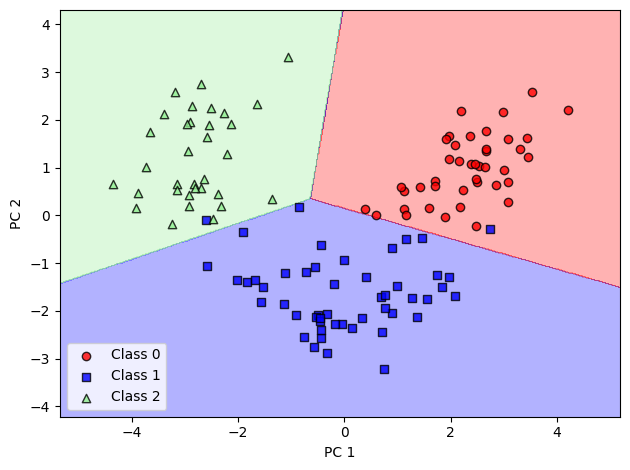

In [ ]:
plot_decision_regions(X_train_pca, y_train, classifier=lr)
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='lower left')
plt.tight_layout()

plt.show()

## Visualize the decision boundary for the test data
For the sake of completeness, let’s plot the decision regions of the logistic regression on the transformed test dataset to see if it can separate the classes well:


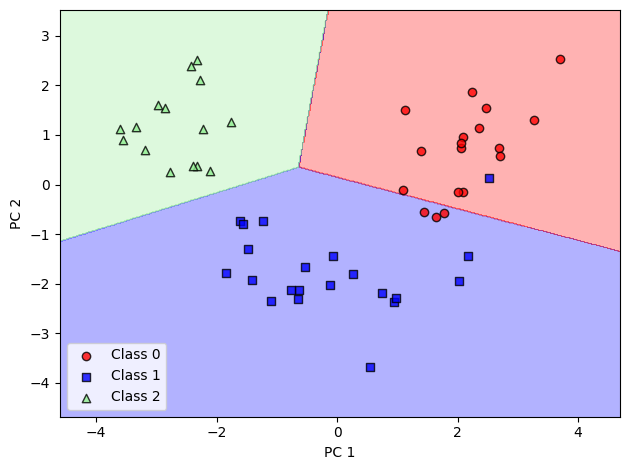

In [ ]:
plot_decision_regions(X_test_pca, y_test, classifier=lr)
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='lower left')
plt.tight_layout()
# plt.savefig('figures/05_05.png', dpi=300)
plt.show()

## Access the explained variance

- If we are interested in the explained variance ratios of the different principal components, we can
simply initialize the PCA class with the n_components parameter set to None.
- All principal components are kept and the explained variance ratio can then be accessed via the explained_variance_ratio_
attribute:

In [ ]:
pca = PCA(n_components=None)
X_train_pca = pca.fit_transform(X_train_std)
pca.explained_variance_ratio_

array([0.36951469, 0.18434927, 0.11815159, 0.07334252, 0.06422108,
       0.05051724, 0.03954654, 0.02643918, 0.02389319, 0.01629614,
       0.01380021, 0.01172226, 0.00820609])

## Assessing feature contributions

- As we learned, via PCA, we create principal components that represent linear combinations of the features.
- Sometimes, we are interested to know about how much each original feature contributes to a given principal component.
- These contributions are often called loadings.
- The factor loadings can be computed by scaling the eigenvectors by the square root of the eigenvalues.
- The resulting values can then be interpreted as the correlation between the original features and
the principal component.
- To illustrate this, let us plot the loadings for the first principal component.
- First, we compute the 13×13-dimensional loadings matrix by multiplying the eigenvectors by the square root of the eigenvalues:

In [ ]:
sklearn_loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

- Then, we plot the loadings for the first principal component, loadings[:, 0], which is the first column in this matrix:

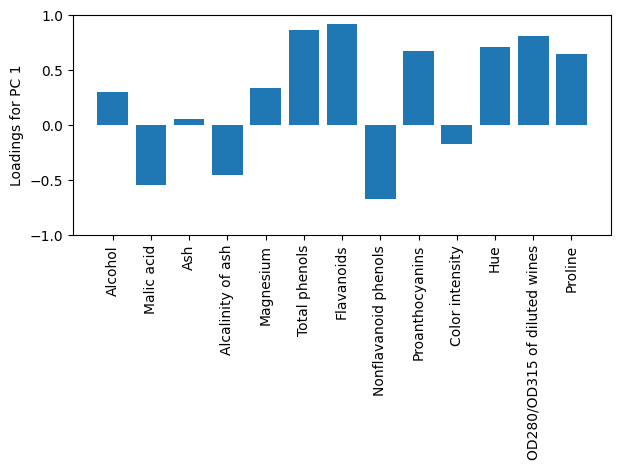

In [ ]:
fig, ax = plt.subplots()

ax.bar(range(13), sklearn_loadings[:, 0], align='center')
ax.set_ylabel('Loadings for PC 1')
ax.set_xticks(range(13))
ax.set_xticklabels(df_wine.columns[:-1], rotation=90)

plt.ylim([-1, 1])
plt.tight_layout()

plt.show()

- Note that a value of 1 describes a perfect positive correlation whereas a value of –1 corresponds to a
perfect negative correlation:

# Retrieval Practice PCA 4

# Why do we need model evaluation and selection?
- Machine learning involves choosing from a variety of algorithms and models.
- We need to compare different models and algorithms to determine which one performs best.
-  Model selection and evaluation help ensure that a chosen model is not overfitting or underfitting, and can be generalized to unseen data.

# Streamlining Workflows with Pipeline

-  How to create and use a pileline?

- Prior to training a model, we may apply a variety of preprocessing techniques on the data, such as standardization for feature scaling.
- We have to reuse the parameters that were obtained during the fitting of the training data to scale and compress any new data.
- Scikit-learn provides an extremely handy tool, the `Pipeline`
class that allows us to fit a model including an arbitrary number of transformation steps and apply it to make predictionsabout new data.

## We will use the Breast Cancer Wisconsin dataset for illustration:
- We will be working with the Breast Cancer Wisconsin dataset, which contains 569 examples of malignant and benign tumor cells.
- The first two columns in the dataset store the unique ID
numbers of the examples and the corresponding diagnoses (M = malignant, B = benign), respectively.
- Columns 3-32 contain 30 real-valued features that have been computed from digitized images of the cell nuclei, which can be used to build a model to predict whether a tumor is benign or malignant.

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Load the Breast Cancer Wisconsin dataset
bc_data = load_breast_cancer()
X = bc_data.data
y = bc_data.target
target_names = bc_data.target_names

print(f"Dataset shape: {X.shape}")
print(f"Target names: {target_names}")

Dataset shape: (569, 30)
Target names: ['malignant' 'benign']


In [ ]:
for y_target in range(2):
    print(y_target, "->", bc_data.target_names[y_target])

0 -> malignant
1 -> benign


Divide the dataset into a separate training dataset (80 percentof the data) and a separate test dataset (20 percent of the data):

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = \
    train_test_split(X, y,
                     test_size=0.20,
                     stratify=y,
                     random_state=1)

## How to combine transformers and estimators in a pipeline?
- We will standardize the columns in the Breast Cancer
Wisconsin dataset before we feed them to a linear classifier, such as logistic regression.
- We can also compress our data from the initial 30 dimensions onto a lower two-dimensional subspace via principal component analysis (PCA).
- We can chain the StandardScaler and LogisticRegression
objects in a pipeline (with or without PCA):

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

pipe_lr = make_pipeline(StandardScaler(),
                        PCA(n_components=2),
                        LogisticRegression(random_state=1, solver='lbfgs'))

In [ ]:
pipe_lr.fit(X_train, y_train)
y_pred = pipe_lr.predict(X_test)
print('Test Accuracy: %.3f' % pipe_lr.score(X_test, y_test))

Test Accuracy: 0.956


The pipelines of the scikit-learn library are immensely useful wrapper tools. To make sure that you've got a good grasp of how the Pipeline object works, please take a close look at the following illustration:
<img src="https://i.imgur.com/1vxItHg.png" width = 800>

## Explain the pipeline:
- The make_pipeline function takes an arbitrary number of scikit-learn transformers (objects that support
the fit and transform methods as input), followed by a scikit-learn estimator that implements the
fit and predict methods.
    - In our example, we provided two scikit-learn transformers,
StandardScaler and PCA, and a LogisticRegression estimator as inputs to the make_pipeline function.
- We can think of a scikit-learn Pipeline as a meta-estimator or wrapper around those individual transformers and estimators.
- If we call the fit method of Pipeline, the data will be passed down a series of transformers via fit and transform calls on these intermediate steps until it arrives at the
estimator object.
- The estimator will then be fitted to the transformed
training data.
- We should note that there is no limit to the number of
intermediate steps in a pipeline; however, if we want to use the pipeline for prediction tasks, the last
pipeline element has to be an estimator.
- Similar to calling fit on a pipeline, pipelines also implement a predict method if the last step in the
pipeline is an estimator.
    - If we feed a dataset to the predict call of a Pipeline object instance, the data will pass through the intermediate steps via transform calls. In the final step, the estimator object will then return a prediction on the transformed data.


# Retrieval Practice on Pipeline